<a href="https://colab.research.google.com/github/Aryamaan777/Finance/blob/Event-Study---Earnings-Day-Impact/Event_Study_Earnings_Day_Impact.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import norm

import yfinance as yf

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
earnings_dates = yf.Ticker('AAPL').earnings_dates.index[1:]

for date in earnings_dates:
  print(date.day_name())

Thursday
Thursday
Thursday
Thursday
Thursday
Thursday
Thursday
Thursday
Thursday
Thursday
Thursday
Thursday
Thursday
Thursday
Thursday
Thursday
Thursday
Tuesday
Wednesday
Wednesday
Thursday
Thursday
Thursday
Tuesday


Confirming All Earnings Days were Weekdays

In [ ]:
for date in earnings_dates:
  print(date.time())

16:00:00
16:00:00
16:00:00
16:00:00
16:00:00
16:00:00
16:00:00
16:00:00
16:00:00
16:00:00
16:00:00
16:00:00
16:00:00
16:00:00
16:00:00
16:00:00
16:00:00
16:00:00
16:00:00
16:00:00
16:00:00
16:00:00
17:00:00
16:00:00


Almost Every Earnings Date is recorded at 4pm, except 1 date which was recorded at 5pm. Might need to look into this to check if earnings date impact was seen on the day recorded, or the next day.

In [ ]:
# Initializing Window
for date in earnings_dates:
  print((date - pd.Timedelta(days=5)).day_name(), (date + pd.Timedelta(days=5)).day_name())

Saturday Tuesday
Saturday Tuesday
Saturday Tuesday
Saturday Tuesday
Saturday Tuesday
Saturday Tuesday
Saturday Tuesday
Saturday Tuesday
Saturday Tuesday
Saturday Tuesday
Saturday Tuesday
Saturday Tuesday
Saturday Tuesday
Saturday Tuesday
Saturday Tuesday
Saturday Tuesday
Saturday Tuesday
Thursday Sunday
Friday Monday
Friday Monday
Saturday Tuesday
Saturday Tuesday
Saturday Tuesday
Thursday Sunday


Since Majority of t-5 lies on Saturdays(non-trading day), let's consider a window of t-6 to t+6

In [ ]:
for date in earnings_dates:
  print((date - pd.Timedelta(days=6)).day_name(), (date + pd.Timedelta(days=6)).day_name())

Friday Wednesday
Friday Wednesday
Friday Wednesday
Friday Wednesday
Friday Wednesday
Friday Wednesday
Friday Wednesday
Friday Wednesday
Friday Wednesday
Friday Wednesday
Friday Wednesday
Friday Wednesday
Friday Wednesday
Friday Wednesday
Friday Wednesday
Friday Wednesday
Friday Wednesday
Wednesday Monday
Thursday Tuesday
Thursday Tuesday
Friday Wednesday
Friday Wednesday
Friday Wednesday
Wednesday Monday


All Weekdays Confirmed

In [ ]:
tickers = ['AAPL', '^GSPC']
data = []
for date in earnings_dates:
  df = yf.download(tickers, start = date.date() - pd.Timedelta(days = 6), end = date.date() + pd.Timedelta(days = 6))['Close']
  data.append(df)

/tmp/ipython-input-3346842258.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers, start = date.date() - pd.Timedelta(days = 6), end = date.date() + pd.Timedelta(days = 6))['Close']
[*********************100%***********************]  2 of 2 completed
/tmp/ipython-input-3346842258.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers, start = date.date() - pd.Timedelta(days = 6), end = date.date() + pd.Timedelta(days = 6))['Close']
[*********************100%***********************]  2 of 2 completed
/tmp/ipython-input-3346842258.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers, start = date.date() - pd.Timedelta(days = 6), end = date.date() + pd.Timedelta(days = 6))['Close']
[*********************100%***********************]  2 of 2 completed
/tmp/ipython-input-3346842258.py:4: FutureWarning: YF.download() has c

In [ ]:
data

[Ticker            AAPL        ^GSPC
 Date                               
 2025-10-24  262.565491  6791.689941
 2025-10-27  268.549652  6875.160156
 2025-10-28  268.739471  6890.890137
 2025-10-29  269.438812  6890.589844
 2025-10-30  271.137146  6822.339844
 2025-10-31  270.108154  6840.200195
 2025-11-03  268.789429  6851.970215
 2025-11-04  269.778473  6771.549805,
 Ticker            AAPL        ^GSPC
 Date                               
 2025-07-25  213.430649  6388.640137
 2025-07-28  213.600296  6389.770020
 2025-07-29  210.826126  6370.859863
 2025-07-30  208.610794  6362.899902
 2025-07-31  207.133911  6339.390137
 2025-08-01  201.954819  6238.009766
 2025-08-04  202.922775  6329.939941
 2025-08-05  202.493668  6299.189941,
 Ticker            AAPL        ^GSPC
 Date                               
 2025-04-25  208.566803  5525.209961
 2025-04-28  209.423874  5528.750000
 2025-04-29  210.490234  5560.830078
 2025-04-30  211.775833  5569.060059
 2025-05-01  212.593048  5604.140137

DatetimeIndex(['2025-10-24', '2025-10-27', '2025-10-28', '2025-10-29',
               '2025-10-30', '2025-10-31', '2025-11-03', '2025-11-04'],
              dtype='datetime64[ns]', name='Date', freq=None)
Date
2025-10-27    0.022791
2025-10-28    0.000707
2025-10-29    0.002602
2025-10-30    0.006303
2025-10-31   -0.003795
2025-11-03   -0.004882
2025-11-04    0.003680
Name: AAPL, dtype: float64


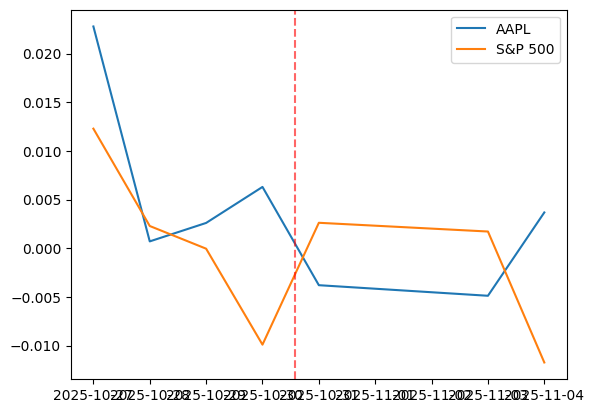

DatetimeIndex(['2025-07-25', '2025-07-28', '2025-07-29', '2025-07-30',
               '2025-07-31', '2025-08-01', '2025-08-04', '2025-08-05'],
              dtype='datetime64[ns]', name='Date', freq=None)
Date
2025-07-28    0.000795
2025-07-29   -0.012988
2025-07-30   -0.010508
2025-07-31   -0.007080
2025-08-01   -0.025004
2025-08-04    0.004793
2025-08-05   -0.002115
Name: AAPL, dtype: float64


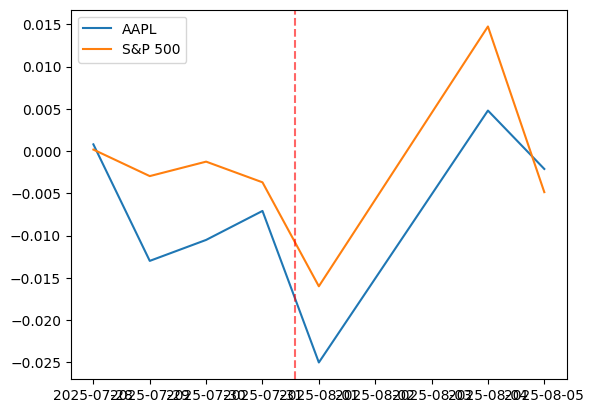

DatetimeIndex(['2025-04-25', '2025-04-28', '2025-04-29', '2025-04-30',
               '2025-05-01', '2025-05-02', '2025-05-05', '2025-05-06'],
              dtype='datetime64[ns]', name='Date', freq=None)
Date
2025-04-28    0.004109
2025-04-29    0.005092
2025-04-30    0.006108
2025-05-01    0.003859
2025-05-02   -0.037362
2025-05-05   -0.031458
2025-05-06   -0.001911
Name: AAPL, dtype: float64


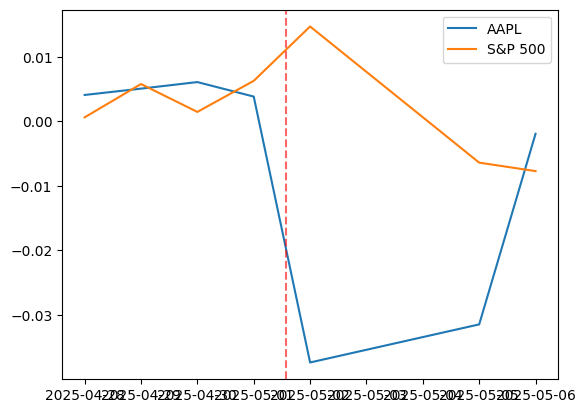

DatetimeIndex(['2025-01-24', '2025-01-27', '2025-01-28', '2025-01-29',
               '2025-01-30', '2025-01-31', '2025-02-03', '2025-02-04'],
              dtype='datetime64[ns]', name='Date', freq=None)
Date
2025-01-27    0.031780
2025-01-28    0.036544
2025-01-29    0.004617
2025-01-30   -0.007395
2025-01-31   -0.006692
2025-02-03   -0.033856
2025-02-04    0.021008
Name: AAPL, dtype: float64


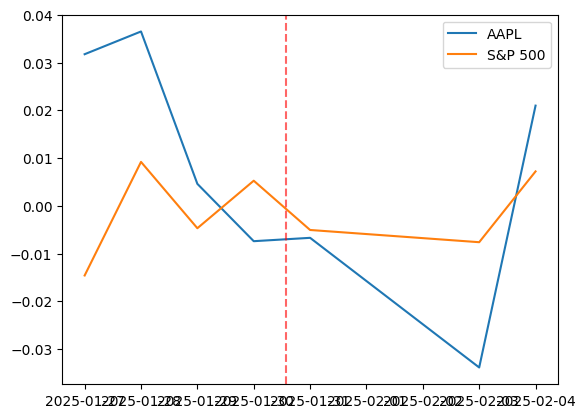

DatetimeIndex(['2024-10-25', '2024-10-28', '2024-10-29', '2024-10-30',
               '2024-10-31', '2024-11-01', '2024-11-04', '2024-11-05'],
              dtype='datetime64[ns]', name='Date', freq=None)
Date
2024-10-28    0.008599
2024-10-29    0.001157
2024-10-30   -0.015278
2024-10-31   -0.018209
2024-11-01   -0.013280
2024-11-04   -0.004037
2024-11-05    0.006486
Name: AAPL, dtype: float64


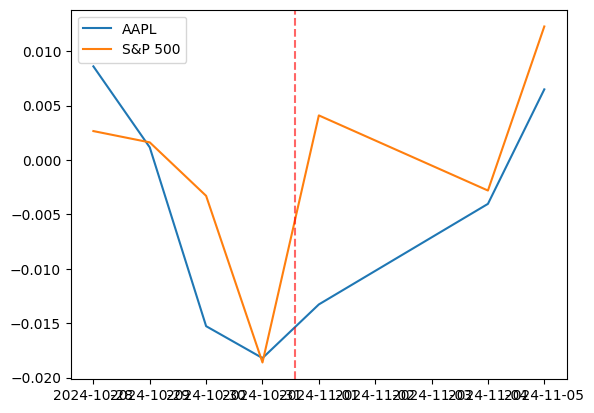

DatetimeIndex(['2024-07-26', '2024-07-29', '2024-07-30', '2024-07-31',
               '2024-08-01', '2024-08-02', '2024-08-05', '2024-08-06'],
              dtype='datetime64[ns]', name='Date', freq=None)
Date
2024-07-29    0.001285
2024-07-30    0.002566
2024-07-31    0.014991
2024-08-01   -0.016751
2024-08-02    0.006869
2024-08-05   -0.048167
2024-08-06   -0.009748
Name: AAPL, dtype: float64


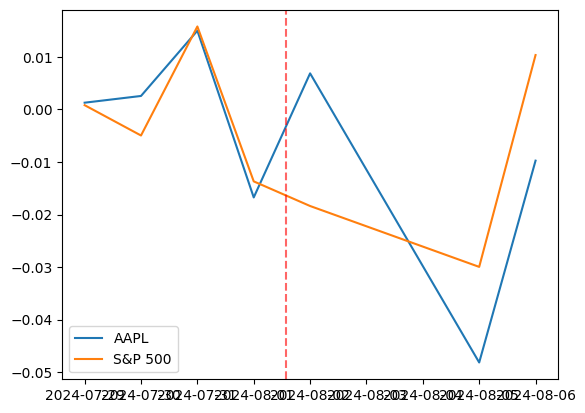

DatetimeIndex(['2024-04-26', '2024-04-29', '2024-04-30', '2024-05-01',
               '2024-05-02', '2024-05-03', '2024-05-06', '2024-05-07'],
              dtype='datetime64[ns]', name='Date', freq=None)
Date
2024-04-29    0.024808
2024-04-30   -0.018271
2024-05-01   -0.006047
2024-05-02    0.022032
2024-05-03    0.059816
2024-05-06   -0.009107
2024-05-07    0.003797
Name: AAPL, dtype: float64


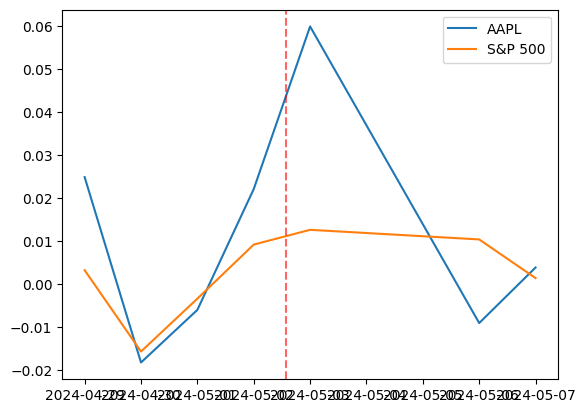

DatetimeIndex(['2024-01-26', '2024-01-29', '2024-01-30', '2024-01-31',
               '2024-02-01', '2024-02-02', '2024-02-05', '2024-02-06'],
              dtype='datetime64[ns]', name='Date', freq=None)
Date
2024-01-29   -0.003586
2024-01-30   -0.019246
2024-01-31   -0.019358
2024-02-01    0.013341
2024-02-02   -0.005405
2024-02-05    0.009847
2024-02-06    0.008632
Name: AAPL, dtype: float64


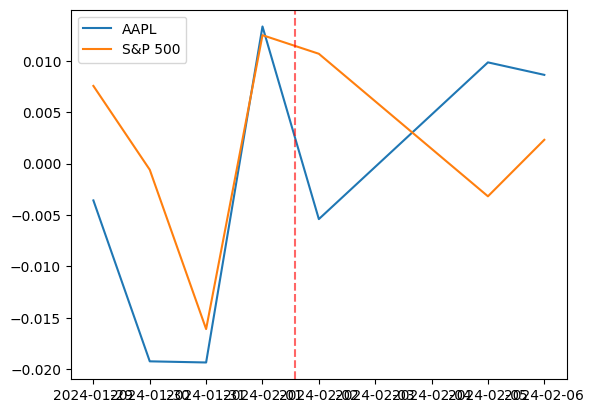

DatetimeIndex(['2023-10-27', '2023-10-30', '2023-10-31', '2023-11-01',
               '2023-11-02', '2023-11-03', '2023-11-06', '2023-11-07'],
              dtype='datetime64[ns]', name='Date', freq=None)
Date
2023-10-30    0.012305
2023-10-31    0.002819
2023-11-01    0.018739
2023-11-02    0.020693
2023-11-03   -0.005181
2023-11-06    0.014605
2023-11-07    0.014451
Name: AAPL, dtype: float64


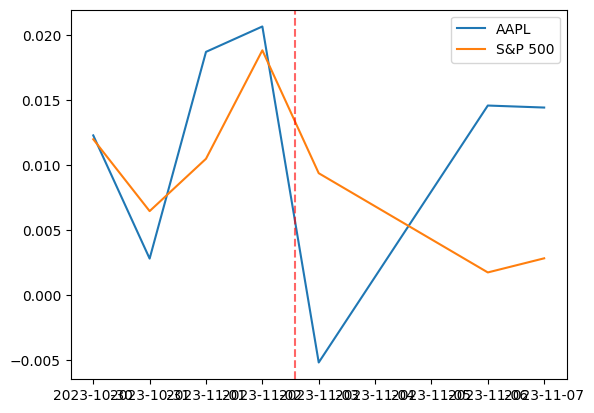

DatetimeIndex(['2023-07-28', '2023-07-31', '2023-08-01', '2023-08-02',
               '2023-08-03', '2023-08-04', '2023-08-07', '2023-08-08'],
              dtype='datetime64[ns]', name='Date', freq=None)
Date
2023-07-31    0.003166
2023-08-01   -0.004276
2023-08-02   -0.015490
2023-08-03   -0.007322
2023-08-04   -0.048020
2023-08-07   -0.017254
2023-08-08    0.005312
Name: AAPL, dtype: float64


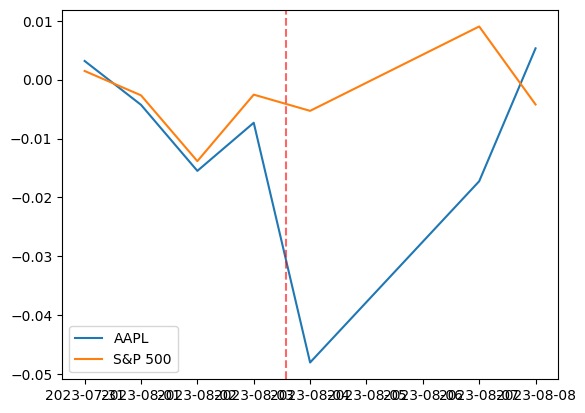

DatetimeIndex(['2023-04-28', '2023-05-01', '2023-05-02', '2023-05-03',
               '2023-05-04', '2023-05-05', '2023-05-08', '2023-05-09'],
              dtype='datetime64[ns]', name='Date', freq=None)
Date
2023-05-01   -0.000530
2023-05-02   -0.006192
2023-05-03   -0.006467
2023-05-04   -0.009913
2023-05-05    0.046927
2023-05-08   -0.000404
2023-05-09   -0.009971
Name: AAPL, dtype: float64


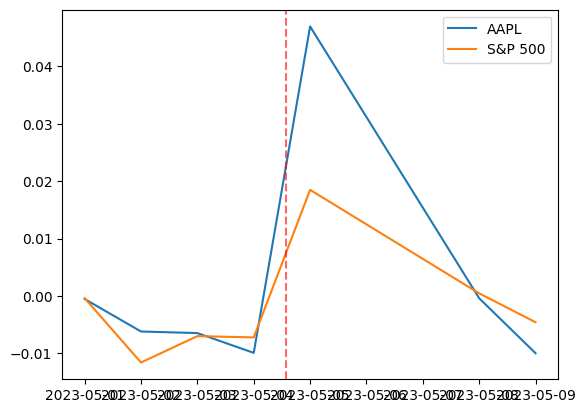

DatetimeIndex(['2023-01-27', '2023-01-30', '2023-01-31', '2023-02-01',
               '2023-02-02', '2023-02-03', '2023-02-06', '2023-02-07'],
              dtype='datetime64[ns]', name='Date', freq=None)
Date
2023-01-30   -0.020078
2023-01-31    0.009021
2023-02-01    0.007901
2023-02-02    0.037062
2023-02-03    0.024400
2023-02-06   -0.017929
2023-02-07    0.019245
Name: AAPL, dtype: float64


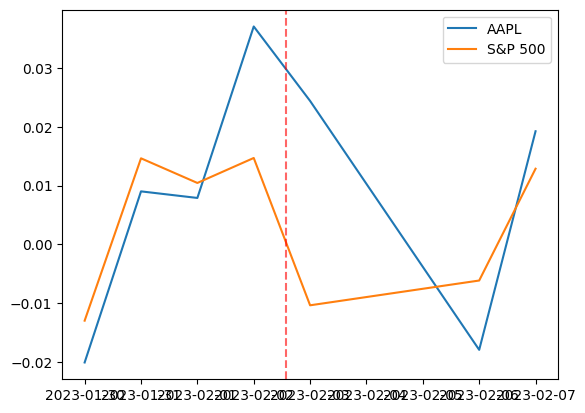

DatetimeIndex(['2022-10-21', '2022-10-24', '2022-10-25', '2022-10-26',
               '2022-10-27', '2022-10-28', '2022-10-31', '2022-11-01'],
              dtype='datetime64[ns]', name='Date', freq=None)
Date
2022-10-24    0.014803
2022-10-25    0.019337
2022-10-26   -0.019627
2022-10-27   -0.030465
2022-10-28    0.075552
2022-10-31   -0.015410
2022-11-01   -0.017543
Name: AAPL, dtype: float64


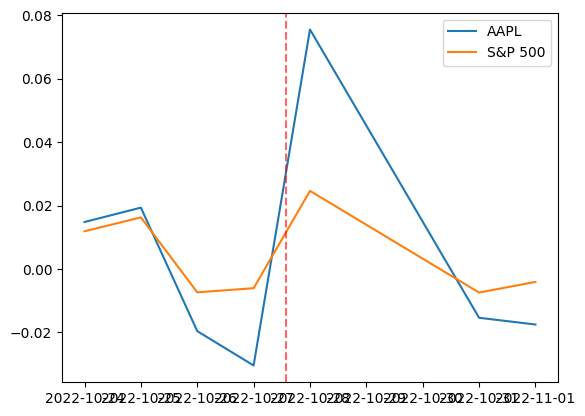

DatetimeIndex(['2022-07-22', '2022-07-25', '2022-07-26', '2022-07-27',
               '2022-07-28', '2022-07-29', '2022-08-01', '2022-08-02'],
              dtype='datetime64[ns]', name='Date', freq=None)
Date
2022-07-25   -0.007398
2022-07-26   -0.008827
2022-07-27    0.034235
2022-07-28    0.003572
2022-07-29    0.032793
2022-08-01   -0.006153
2022-08-02   -0.009287
Name: AAPL, dtype: float64


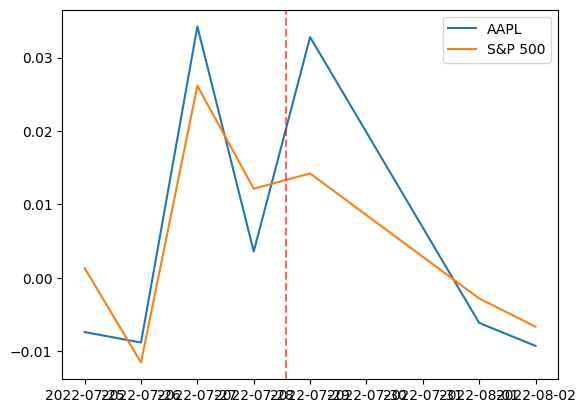

DatetimeIndex(['2022-04-22', '2022-04-25', '2022-04-26', '2022-04-27',
               '2022-04-28', '2022-04-29', '2022-05-02', '2022-05-03'],
              dtype='datetime64[ns]', name='Date', freq=None)
Date
2022-04-25    0.006737
2022-04-26   -0.037328
2022-04-27   -0.001467
2022-04-28    0.045155
2022-04-29   -0.036605
2022-05-02    0.001967
2022-05-03    0.009622
Name: AAPL, dtype: float64


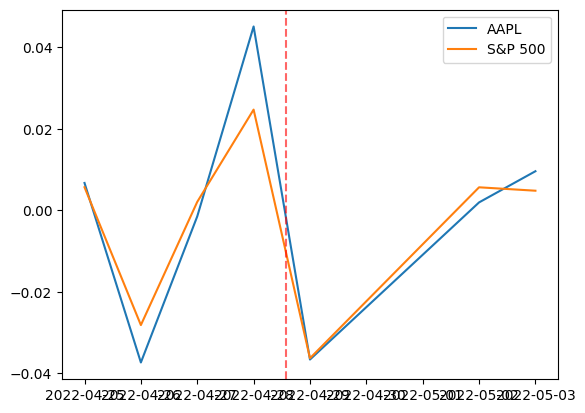

DatetimeIndex(['2022-01-21', '2022-01-24', '2022-01-25', '2022-01-26',
               '2022-01-27', '2022-01-28', '2022-01-31', '2022-02-01'],
              dtype='datetime64[ns]', name='Date', freq=None)
Date
2022-01-24   -0.004864
2022-01-25   -0.011385
2022-01-26   -0.000563
2022-01-27   -0.002943
2022-01-28    0.069778
2022-01-31    0.026126
2022-02-01   -0.000973
Name: AAPL, dtype: float64


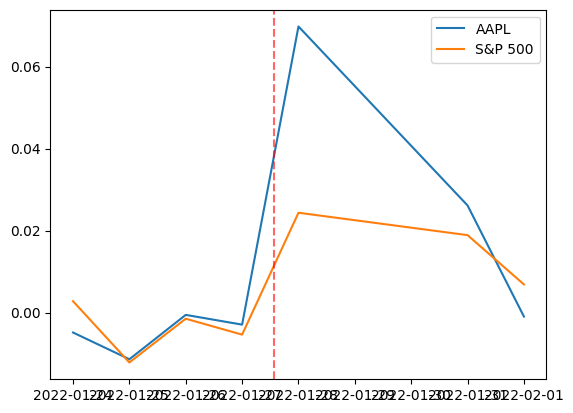

DatetimeIndex(['2021-10-22', '2021-10-25', '2021-10-26', '2021-10-27',
               '2021-10-28', '2021-10-29', '2021-11-01', '2021-11-02'],
              dtype='datetime64[ns]', name='Date', freq=None)
Date
2021-10-25   -0.000336
2021-10-26    0.004575
2021-10-27   -0.003148
2021-10-28    0.024991
2021-10-29   -0.018156
2021-11-01   -0.005607
2021-11-02    0.007116
Name: AAPL, dtype: float64


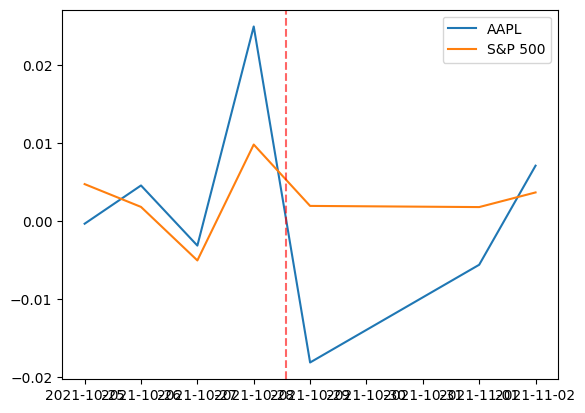

DatetimeIndex(['2021-07-21', '2021-07-22', '2021-07-23', '2021-07-26',
               '2021-07-27', '2021-07-28', '2021-07-29', '2021-07-30'],
              dtype='datetime64[ns]', name='Date', freq=None)
Date
2021-07-22    0.009628
2021-07-23    0.011989
2021-07-26    0.002894
2021-07-27   -0.014900
2021-07-28   -0.012196
2021-07-29    0.004553
2021-07-30    0.001511
Name: AAPL, dtype: float64


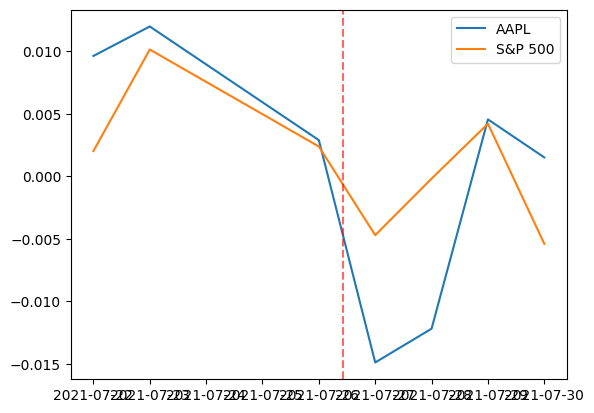

DatetimeIndex(['2021-04-22', '2021-04-23', '2021-04-26', '2021-04-27',
               '2021-04-28', '2021-04-29', '2021-04-30', '2021-05-03'],
              dtype='datetime64[ns]', name='Date', freq=None)
Date
2021-04-23    0.018038
2021-04-26    0.002978
2021-04-27   -0.002450
2021-04-28   -0.006027
2021-04-29   -0.000749
2021-04-30   -0.015133
2021-05-03    0.008215
Name: AAPL, dtype: float64


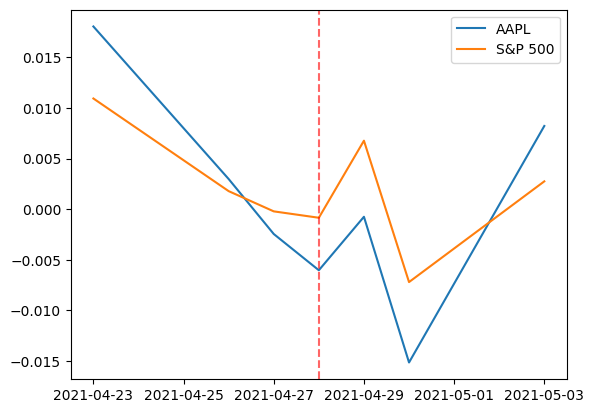

DatetimeIndex(['2021-01-21', '2021-01-22', '2021-01-25', '2021-01-26',
               '2021-01-27', '2021-01-28', '2021-01-29', '2021-02-01'],
              dtype='datetime64[ns]', name='Date', freq=None)
Date
2021-01-22    0.016074
2021-01-25    0.027684
2021-01-26    0.001679
2021-01-27   -0.007684
2021-01-28   -0.034985
2021-01-29   -0.037421
2021-02-01    0.016520
Name: AAPL, dtype: float64


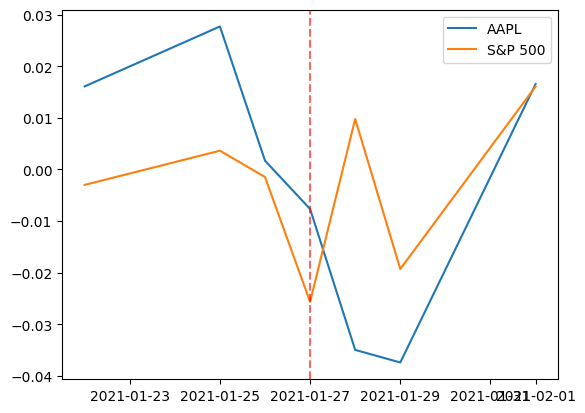

DatetimeIndex(['2020-10-23', '2020-10-26', '2020-10-27', '2020-10-28',
               '2020-10-29', '2020-10-30', '2020-11-02', '2020-11-03'],
              dtype='datetime64[ns]', name='Date', freq=None)
Date
2020-10-26    0.000087
2020-10-27    0.013472
2020-10-28   -0.046312
2020-10-29    0.037050
2020-10-30   -0.056018
2020-11-02   -0.000827
2020-11-03    0.015354
Name: AAPL, dtype: float64


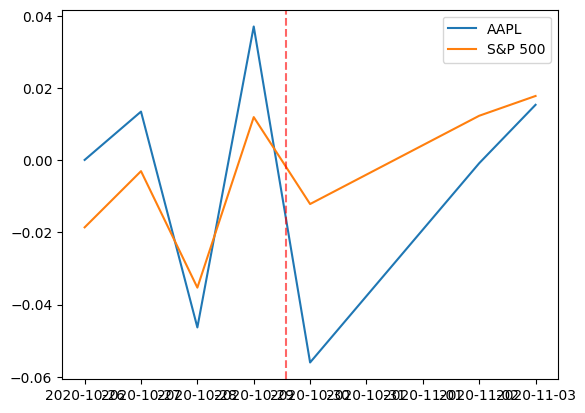

DatetimeIndex(['2020-07-24', '2020-07-27', '2020-07-28', '2020-07-29',
               '2020-07-30', '2020-07-31', '2020-08-03', '2020-08-04'],
              dtype='datetime64[ns]', name='Date', freq=None)
Date
2020-07-27    0.023700
2020-07-28   -0.016428
2020-07-29    0.019169
2020-07-30    0.012100
2020-07-31    0.104689
2020-08-03    0.025198
2020-08-04    0.006678
Name: AAPL, dtype: float64


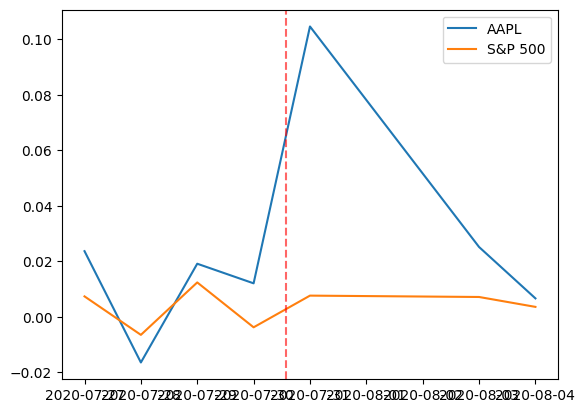

DatetimeIndex(['2020-04-24', '2020-04-27', '2020-04-28', '2020-04-29',
               '2020-04-30', '2020-05-01', '2020-05-04', '2020-05-05'],
              dtype='datetime64[ns]', name='Date', freq=None)
Date
2020-04-27    0.000707
2020-04-28   -0.016209
2020-04-29    0.032845
2020-04-30    0.021096
2020-05-01   -0.016100
2020-05-04    0.014149
2020-05-05    0.015009
Name: AAPL, dtype: float64


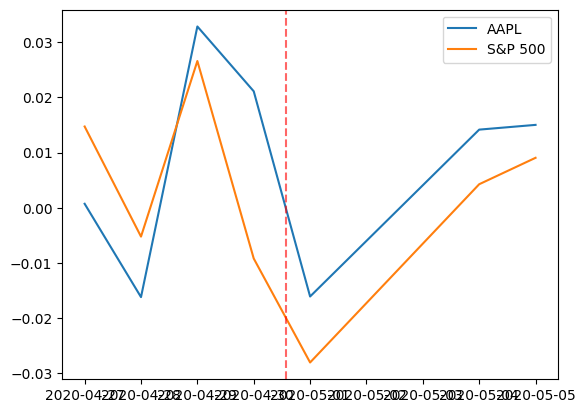

DatetimeIndex(['2020-01-22', '2020-01-23', '2020-01-24', '2020-01-27',
               '2020-01-28', '2020-01-29', '2020-01-30', '2020-01-31'],
              dtype='datetime64[ns]', name='Date', freq=None)
Date
2020-01-23    0.004816
2020-01-24   -0.002882
2020-01-27   -0.029406
2020-01-28    0.028290
2020-01-29    0.020932
2020-01-30   -0.001449
2020-01-31   -0.044339
Name: AAPL, dtype: float64


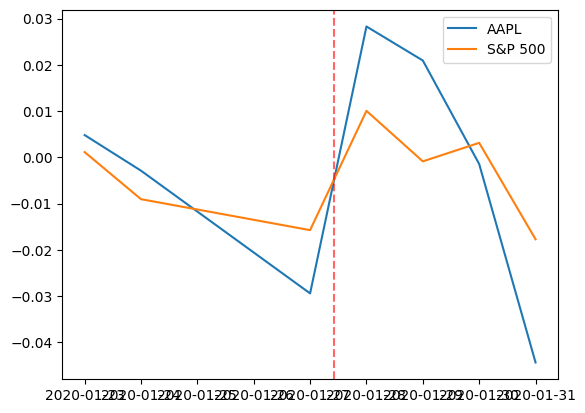

In [ ]:
for df in data:
  AAPL_returns = df['AAPL'].pct_change().dropna()
  SP500_returns = df['^GSPC'].pct_change().dropna()

  print(df.index)
  print(AAPL_returns)

  plt.plot(AAPL_returns.index, AAPL_returns.values, label = 'AAPL')
  plt.plot(AAPL_returns.index, SP500_returns.values, label = 'S&P 500')
  plt.legend()
  plt.axvline(AAPL_returns.index.mean(), color='red', linestyle='--', alpha=0.6, label='Correlation = 0')
  plt.show()

In [ ]:
# 1. Setup
ticker_symbol = 'AAPL'
index_symbol = '^GSPC'
window_size = 5  # Days before and after

In [ ]:
# 2. Get Earnings Dates and Clean them
ticker_obj = yf.Ticker(ticker_symbol)
# Filter for past dates only and remove timezone info
earnings_dates = ticker_obj.earnings_dates.index
earnings_dates = earnings_dates[earnings_dates < pd.Timestamp.now(tz='UTC')].tz_localize(None)

In [ ]:
# 3. Download a large block of data once (more efficient than multiple downloads)
start_data = earnings_dates.min() - pd.Timedelta(days=20)
end_data = earnings_dates.max() + pd.Timedelta(days=20)
all_data = yf.download([ticker_symbol, index_symbol], start=start_data, end=end_data)['Close']
all_returns = all_data.pct_change().dropna()

/tmp/ipython-input-2939312936.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  all_data = yf.download([ticker_symbol, index_symbol], start=start_data, end=end_data)['Close']
[*********************100%***********************]  2 of 2 completed


In [ ]:
# 4. Storage for results
event_results = []

for event_date in earnings_dates:
    try:
        # Find the trading day index closest to the earnings date
        # If earnings were after hours, Day 0 is usually the NEXT trading day
        # We find the location of the event_date in our returns dataframe
        idx = all_returns.index.get_indexer([event_date], method='nearest')[0]

        # Slice the window (-5 to +5)
        # We need window_size before, the event day, and window_size after
        subset = all_returns.iloc[idx - window_size : idx + window_size + 1].copy()

        if len(subset) < (2 * window_size + 1):
            continue

        # Calculate Abnormal Return (AR)
        subset['AR'] = subset[ticker_symbol] - subset[index_symbol]

        # Calculate Cumulative Abnormal Return (CAR)
        subset['CAR'] = subset['AR'].cumsum()

        # Re-index to relative days (-5, -4... 0 ... 5)
        subset['Relative_Day'] = np.arange(-window_size, window_size + 1)

        event_results.append(subset[['Relative_Day', 'CAR']])

    except Exception as e:
        print(f"Skipping {event_date}: {e}")

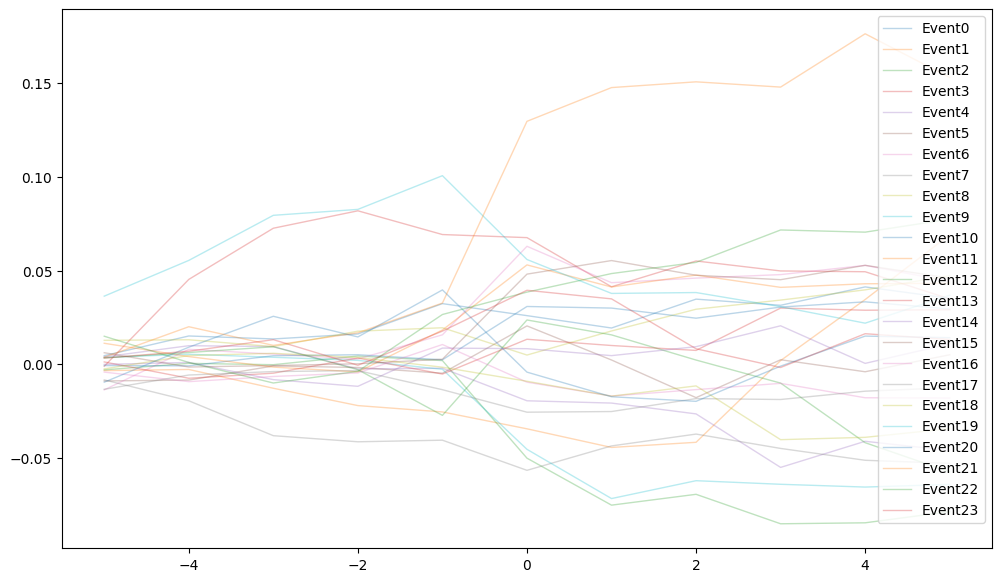

In [ ]:
# 5. Plotting the "Spaghetti Plot"
plt.figure(figsize=(12, 7))

all_cars = []

for i, df_event in enumerate(event_results):
    plt.plot(df_event['Relative_Day'], df_event['CAR'], alpha=0.3, lw=1, label = "Event" + str(i))
    all_cars.append(df_event['CAR'].values)

plt.legend()
plt.show()

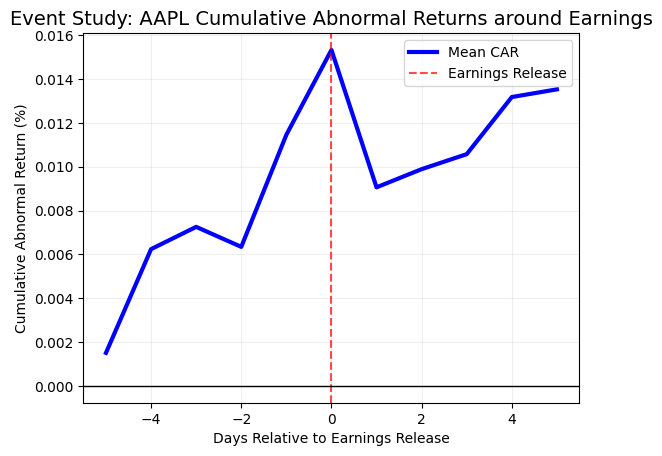

In [ ]:
# 6. Plot the Mean CAR (The "Signal")
mean_car = np.mean(all_cars, axis=0)
plt.plot(np.arange(-window_size, window_size + 1), mean_car, color='blue', lw=3, label='Mean CAR')

# Formatting
plt.axvline(0, color='red', linestyle='--', alpha=0.7, label='Earnings Release')
plt.axhline(0, color='black', lw=1)
plt.title(f'Event Study: {ticker_symbol} Cumulative Abnormal Returns around Earnings', fontsize=14)
plt.xlabel('Days Relative to Earnings Release')
plt.ylabel('Cumulative Abnormal Return (%)')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()